In [1]:
from pathlib import Path
import hashlib, csv, re, sys
import numpy as np
import h5py
import spe_loader as sl
import json
from typing import Any
from lightfield_processing import *
import matplotlib.pyplot as plt

In [2]:
RAW_DIR   = Path("G:\\Shared drives\\Shumlak Lab\\Diagnostics\\Spectroscopy\\S_XB\\Data\\Ops")
OUT_H5    = Path("G:\\Shared drives\\Shumlak Lab\\Users\\Current\\Elyse Lian\\Python Code\\Spectroscopy\\experiment.h5")
MANIFEST  = Path("G:\\Shared drives\\Shumlak Lab\\Users\\Current\\Elyse Lian\\Python Code\\Spectroscopy\\manifest.csv")

(1024, 1024)
8847.095110416412


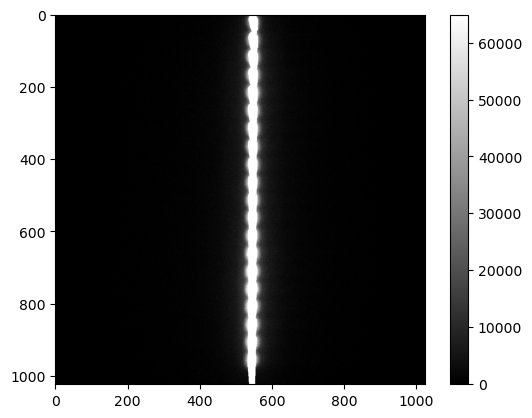

In [3]:
attrs = get_shot_attributes(OUT_H5, shot_id=250219017)
img = attrs["image"]
print(img.shape) 
print(attrs["dataset_attrs"]["Acceleration Voltage (kV)"])

plt.imshow(img, cmap='gray')
plt.colorbar()

In [4]:
import h5py

with h5py.File(OUT_H5, "r") as f:
    print("Top-level keys:", list(f.keys()))
    if "shots" in f:
        keys = list(f["shots"].keys())
        print("Number of shots:", len(keys))
        print("First 20 shot keys:", keys[:20])
        print("Contains 250219017?", "250219017" in keys)
        # Also check legacy style
        print("Contains 250219_017?", "250219_017" in keys)
        print("Contains 250219_17?", "250219_17" in keys)

Top-level keys: ['meta', 'shots']
Number of shots: 384
First 20 shot keys: ['250219017', '250219018', '250219019', '250219020', '250219021', '250219022', '250219023', '250219024', '250219025', '250219026', '250416002', '250416003', '250416004', '250416005', '250416006', '250416007', '250423001', '250423002', '250423003', '250423004']
Contains 250219017? True
Contains 250219_017? False
Contains 250219_17? False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Testing file: G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422\250422  020.spe
Shape: (1024, 1024)
Dtype: float32


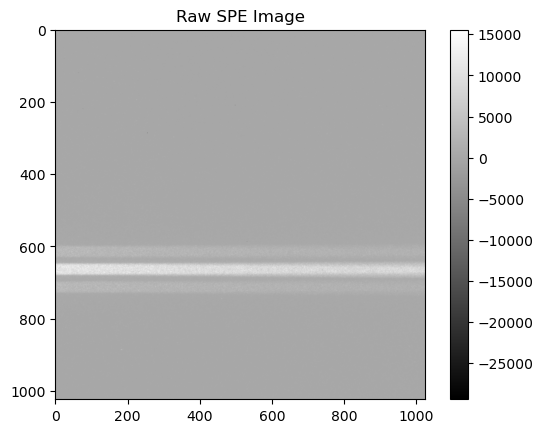

In [26]:
%load_ext autoreload
%autoreload 2

from regions_processing import *

# test_file = os.path.join(CAL_FOLDER, f"{CAL_PREFIX}  007.spe")
test_file = r"G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422\250422  020.spe"

print("Testing file:", test_file)

img = load_spe_image(test_file)

print("Shape:", img.shape)
print("Dtype:", img.dtype)
# print("Min / Max:", img.min(), img.max())
# attrs = get_shot_attributes(OUT_H5, shot_id=250422015)
# gate_shot = attrs["dataset_attrs"]["Gate Width (ns)"]

plt.imshow(img, cmap='gray')
plt.title("Raw SPE Image")
plt.colorbar()
plt.show()

Found 29 SPE files


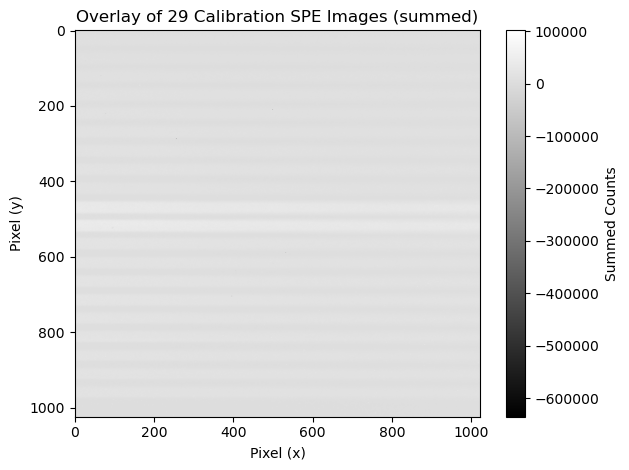

In [35]:
from pathlib import Path

cal_folder = Path(r"G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422")
spe_files = sorted(cal_folder.glob("*.spe"))

print(f"Found {len(spe_files)} SPE files")

# Load all images and sum them into one overlay
stacked = None
for f in spe_files:
    img = load_spe_image(str(f))
    if stacked is None:
        stacked = img.astype(np.float64)
    else:
        stacked += img.astype(np.float64)

plt.figure()
plt.imshow(stacked, cmap='gray', aspect='auto')
plt.title(f"Overlay of {len(spe_files)} Calibration SPE Images (summed)")
plt.xlabel("Pixel (x)")
plt.ylabel("Pixel (y)")
plt.colorbar(label="Summed Counts")
plt.tight_layout()
plt.show()

<unknown>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<unknown>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\regions_processing.py:23: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  """


BBox: (0, 452, 1024, 34)
Centroid: (469, 502)
Area: 29073


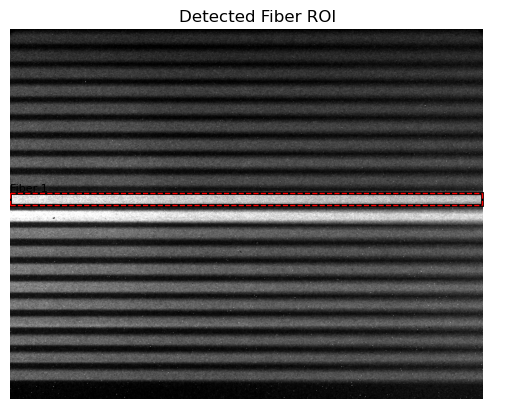

In [33]:
fiber = extract_fiber_and_calibrate(
    stacked,
    lamp_csv_path=LAMP_CSV_PATH,
    sauvola_k=0.01,
    smooth_window=5)

if fiber is None:
    print("No region found.")
else:
    print("BBox:", fiber["bbox"])
    print("Centroid:", fiber["centroid_index"])
    print("Area:", fiber["area"])

    show_fiber_boxes(stacked, [fiber], title="Detected Fiber ROI")

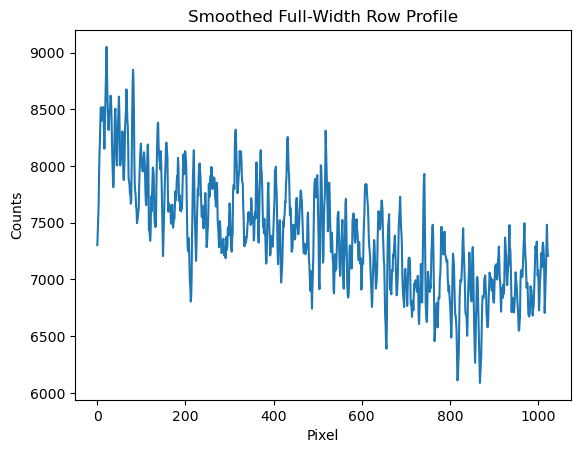

In [48]:
row_profile = fiber["row_profile_full"]

plt.plot(row_profile)
plt.title("Smoothed Full-Width Row Profile")
plt.xlabel("Pixel")
plt.ylabel("Counts")
plt.show()

Multiplier shape: (1024,)


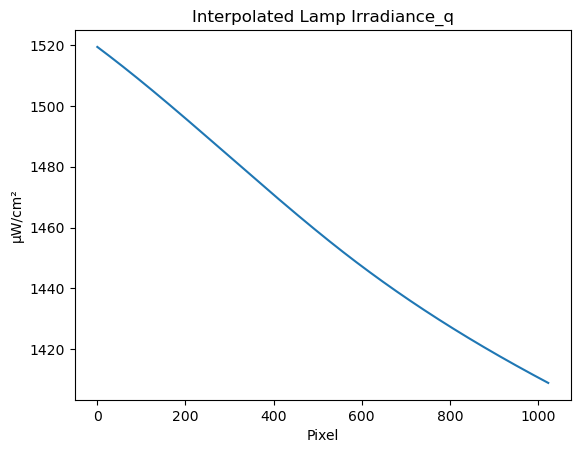

In [55]:
irr_test = get_irradiance_multiplier(
    row_profile,
    lamp_csv_path=LAMP_CSV_PATH)

print("Multiplier shape:", irr_test["multiplier_uW_cm2_per_count"].shape)

plt.plot(irr_test["irradiance_q_uW_cm2"])
plt.title("Interpolated Lamp Irradiance_q")
plt.xlabel("Pixel")
plt.ylabel("µW/cm²")
plt.show()

Multiplier min/max: 0.1676242892113996 0.23349226668653023


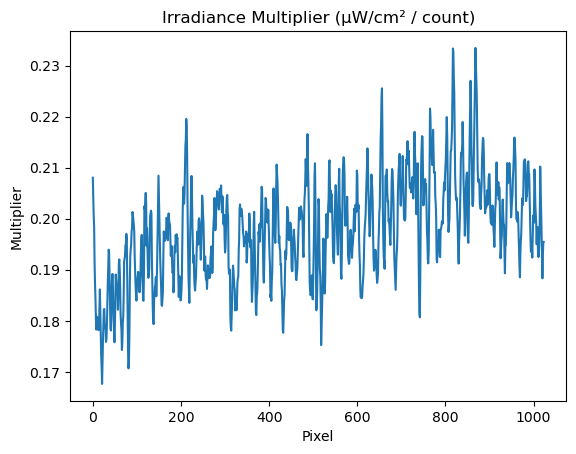

In [ ]:
mult = fiber["irradiance_multiplier"]
plt.plot(mult)
plt.title("Irradiance Multiplier (µW/cm² / count)")
plt.xlabel("Pixel")
plt.ylabel("Multiplier")
plt.show()

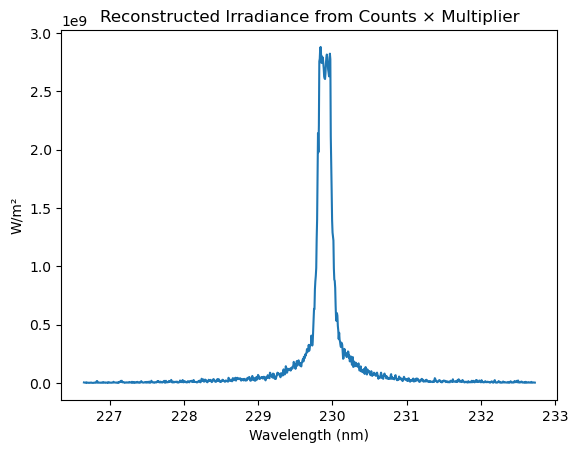

In [70]:
test_row_profile = img[511,:]
test_shot_gate = attrs["dataset_attrs"]["Gate Width (ns)"]
gate_ratio = 20.999 / (test_shot_gate * 1e-9)
calibrated_irradiance = test_row_profile * mult * 1e-6 * 1e4 * gate_ratio

plt.plot(irr_test["wavelength_nm"], calibrated_irradiance)
plt.title("Reconstructed Irradiance from Counts × Multiplier")
plt.xlabel("Wavelength (nm)")
plt.ylabel("W/m²")
plt.show()